# Capítulo 3 — Ejercicios resueltos

Soluciones de los 6 ejercicios de la sección 3.10, con la explicación de **por qué** sale lo que sale.

Cada ejercicio empieza con su enunciado, copiado de `03_regresion.ipynb`, donde están también
las pistas. Este notebook es autocontenido:
recarga los datos y redefine lo que necesita. Como en el resto del proyecto, las semillas están fijadas
(`random_state=4`, `default_rng(4)`) para que las cifras del texto coincidan con las celdas.

| Ej. | Tema | Pregunta |
|---|---|---|
| 1 | overfitting | ¿se puede sobreajustar con features redundantes y sin ruido? |
| 2 | overfitting | ¿más datos reducen la varianza? Comprobarlo con *k-fold* |
| 3 | regularización | L1 con 35 moléculas: ¿qué pesos se anulan primero y por qué? |
| 4 | regularización | ¿se anulan siempre los mismos? |
| 5 | regularización | implementar L-infinito |
| 6 | evaluación | el mejor modelo lineal para todo el dataset, y cómo evaluarlo |

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import rdkit
import rdkit.Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors, rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.linear_model import Lasso, lasso_path
from sklearn.model_selection import KFold
from sklearn.preprocessing import PolynomialFeatures
from scipy.optimize import minimize
from scipy.stats import spearmanr

RDLogger.DisableLog("rdApp.*")

soldata = pd.read_csv("../data/curated-solubility-dataset.csv")
features_start_at = list(soldata.columns).index("MolWt")
feature_names = list(soldata.columns[features_start_at:])
X_all = soldata[feature_names].values
y_all = soldata["Solubility"].values

COLORES = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#eda100"]


def estilo(ax):
    ax.grid(alpha=0.2)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)


print(f"{len(soldata)} moléculas, {len(feature_names)} features")

9982 moléculas, 17 features


---
## 3.10.1 Overfitting

### Ejercicio 1 — features redundantes, sin ruido

> **Enunciado.** ¿Qué pasa si hay **features redundantes pero no hay ruido**? ¿Se puede sobreajustar?

"Redundante" puede querer decir tres cosas distintas, y la respuesta cambia con cada una:

1. **Dependencia lineal exacta**: una feature es combinación de otras. Es el caso de
   `RingCount = NumAromaticRings + NumAliphaticRings` en nuestros descriptores.
2. **Features que sobran**: no hacen falta para describir $f$. Por ejemplo $x^5$ o $\sin x$ para el
   polinomio cúbico de 3.2.1.
3. **Más features que datos**: aunque ninguna sea combinación exacta de otras, con $p$ features y $N < p$
   datos las features ya no pueden ser independientes *en esos datos*.

Usamos el mismo montaje de 3.2.1: $f(x) = x^3 - x^2 + x - 1$, 20 puntos entre −3 y 3, los 10 de los
extremos para entrenar y los 10 del centro para examinar. **Sin ruido**: las labels de train son la $f$
exacta. Ajustamos con `np.linalg.lstsq`, que da el mínimo exacto del MSE.

`lstsq` devuelve cuatro cosas. Nos interesan los pesos y el **rango** (`rank`): el número de
columnas linealmente independientes de la matriz de train. Si el rango es menor que el número de
features, hay infinitas combinaciones de pesos con el mismo error, y `lstsq` elige la de **norma mínima**
(la de pesos más pequeños).

In [2]:
N = 20
syn_x = np.linspace(-3, 3, N)
syn_f = syn_x**3 - syn_x**2 + syn_x - 1          # no noise anywhere
indices = list(range(0, N // 4)) + list(range(3 * N // 4, N))
test_indices = list(range(N // 4, 3 * N // 4))

exact = np.vstack([syn_x**3, syn_x**2, syn_x, np.ones_like(syn_x)]).T
casos = {
    "exactas [x^3, x^2, x, 1]": exact,
    "1. + 2x y x + x^2 (dependientes)": np.c_[exact, 2 * syn_x, syn_x + syn_x**2],
    "1. exactas duplicadas": np.c_[exact, exact],
    "2. + sin x, cos x, exp(-x^2)": np.c_[exact, np.sin(syn_x), np.cos(syn_x), np.exp(-syn_x**2)],
    "2. x^0 .. x^6": np.vstack([syn_x**i for i in range(7)]).T,
    "2. x^0 .. x^9": np.vstack([syn_x**i for i in range(10)]).T,
    "3. x^0 .. x^10": np.vstack([syn_x**i for i in range(11)]).T,
    "3. x^0 .. x^12": np.vstack([syn_x**i for i in range(13)]).T,
    "3. x^0 .. x^15": np.vstack([syn_x**i for i in range(16)]).T,
}
filas, pesos_ej1 = [], {}
for nombre, F in casos.items():
    w, _, rango, _ = np.linalg.lstsq(F[indices], syn_f[indices], rcond=None)
    pesos_ej1[nombre] = w
    filas.append({"features": nombre, "p": F.shape[1], "rango (train)": rango,
                  "MSE train": np.mean((F[indices] @ w - syn_f[indices]) ** 2),
                  "MSE test": np.mean((F[test_indices] @ w - syn_f[test_indices]) ** 2)})
tabla_ej1 = pd.DataFrame(filas).set_index("features")
with pd.option_context("display.float_format", "{:.2g}".format):
    print(tabla_ej1.to_string())
print()
with np.printoptions(precision=3, suppress=True):
    for nombre in ["1. + 2x y x + x^2 (dependientes)", "1. exactas duplicadas", "2. x^0 .. x^6",
                   "3. x^0 .. x^12"]:
        print(f"{nombre:34s} w = {pesos_ej1[nombre]}")

                                   p  rango (train)  MSE train  MSE test
features                                                                
exactas [x^3, x^2, x, 1]           4              4    2.6e-29   1.1e-29
1. + 2x y x + x^2 (dependientes)   6              4    3.6e-28   8.9e-30
1. exactas duplicadas              8              4    3.5e-29   1.1e-29
2. + sin x, cos x, exp(-x^2)       7              7    1.2e-28   1.8e-25
2. x^0 .. x^6                      7              7    3.6e-26   6.1e-26
2. x^0 .. x^9                     10             10    2.9e-24   8.1e-23
3. x^0 .. x^10                    11             10    4.5e-24   7.4e-07
3. x^0 .. x^12                    13             10    8.2e-22      0.21
3. x^0 .. x^15                    16             10    4.2e-20       1.4

1. + 2x y x + x^2 (dependientes)   w = [ 1.    -0.636  0.273 -1.     0.545 -0.364]
1. exactas duplicadas              w = [ 0.5 -0.5  0.5 -0.5  0.5 -0.5  0.5 -0.5]
2. x^0 .. x^6                   

**Qué se ve, caso por caso** (los números del orden de $10^{-20}$ o menores son 0 más el error de redondeo
del ordenador):

- **Exactas**: error 0 en train y en test. Es la referencia.
- **Caso 1, dependencia exacta** (`2x`, `x + x²`, o todo duplicado): el rango se queda en 4 aunque haya 6 u 8
  features, y el error de test sigue siendo 0. Lo que cambia son **los pesos**. Con las columnas duplicadas,
  `lstsq` reparte cada peso a medias (0.5 y 0.5 en lugar de 1). Con `2x` y `x + x²`, los pesos individuales
  no se parecen a los verdaderos: el de $x$ es 0.273. Pero si se suma todo lo que acaba multiplicando a $x$,
  $0.273 + 2 \cdot 0.545 - 0.364 = 1.0$, sale el valor correcto. **La predicción es la misma; los pesos dejan
  de tener significado.** Es la multicolinealidad del capítulo 2 en estado puro.
- **Caso 2, features que sobran** ($\sin x$, $x^4$ a $x^9$): error 0 en test y los pesos de las features
  que sobran salen **exactamente 0**. Sin ruido, no hay nada que las features de más puedan aprender.
- **Caso 3, más features que datos** (11, 13 y 16 features con 10 puntos): el error de train sigue siendo 0,
  pero el de test **ya no**: $7 \cdot 10^{-7}$ con 11 features, **0.21** con 13 y **1.4** con 16.

¿Por qué falla el caso 3 sin ruido? Con 13 incógnitas y 10 ecuaciones hay infinitas soluciones que pasan
exactamente por los 10 puntos. La verdadera es una de ellas, pero los datos no permiten distinguirla de las
demás. `lstsq` elige la de norma mínima, que no tiene por qué ser la verdadera: con $x^0..x^{12}$ pone
$-0.462$ en la constante (en vez de $-1$) y lo compensa con $x^4$, $x^6$... En los 10 puntos de train todas
esas soluciones coinciden; en el centro, donde está el test, no.

#### Lo mismo con descriptores reales

Con la solubilidad no podemos quitar el ruido: el experimento es el que es. Pero sí podemos fabricar
labels **sin ruido** que un modelo lineal pueda reproducir exactamente: ajustamos el modelo lineal a las
9982 moléculas y usamos **sus predicciones** como labels. Llamamos a esas labels `y_clean`. Por
construcción, existe un $\vec w$ que las acierta todas.

Los 17 descriptores tienen una dependencia exacta (`RingCount`), así que es el caso 1 con features
reales. Después entrenamos con $N$ moléculas al azar y examinamos con las demás, 200 veces para cada
$N$. Hay 16 descriptores independientes más el término constante: 17 números que determinar.

In [3]:
Z_all = (X_all - X_all.mean(axis=0)) / X_all.std(axis=0)
A_all = np.c_[Z_all, np.ones(len(Z_all))]
coef_all, _, rango_all, _ = np.linalg.lstsq(A_all, y_all, rcond=None)
y_clean = A_all @ coef_all   # noise-free labels that a linear model can reproduce exactly
print(f"rango de las 17 features + constante (9982 moléculas): {rango_all}")
print(f"varianza de y_clean: {y_clean.var():.2f}   (predecir la media de y_clean daría este MSE)")

rng = np.random.default_rng(4)
filas = []
for n in [5, 10, 15, 17, 20, 25, 35, 50]:
    for _ in range(200):
        perm = rng.permutation(len(y_clean))
        tr, te = perm[:n], perm[n:]
        c, _, rango, _ = np.linalg.lstsq(A_all[tr], y_clean[tr], rcond=None)
        filas.append({"N": n, "rango": rango,
                      "train": np.mean((A_all[tr] @ c - y_clean[tr]) ** 2),
                      "test": np.mean((A_all[te] @ c - y_clean[te]) ** 2)})
res_clean = pd.DataFrame(filas)
res_clean["rango completo"] = res_clean["rango"] == rango_all
resumen = res_clean.groupby("N").agg(
    MSE_train_max=("train", "max"), MSE_test_mediana=("test", "median"),
    MSE_test_max=("test", "max"), repartos_con_rango_incompleto=("rango completo", lambda s: (~s).sum()))
with pd.option_context("display.float_format", "{:.3g}".format):
    print(resumen.to_string())
completo = res_clean[res_clean["rango completo"]]
print(f"\ncon rango completo (N >= 17): MSE test máximo = {completo['test'].max():.1e}")

rango de las 17 features + constante (9982 moléculas): 17
varianza de y_clean: 2.88   (predecir la media de y_clean daría este MSE)


    MSE_train_max  MSE_test_mediana  MSE_test_max  repartos_con_rango_incompleto
N                                                                               
5        1.16e-27              4.85          20.5                            200
10       5.91e-27              1.11          6.85                            200
15       5.05e-27             0.515          5.21                            200
17       4.16e-27          7.94e-28          3.93                             21
20       9.17e-27          1.54e-28         0.635                             10
25       5.56e-27           7.3e-29         0.635                             10
35       2.58e-27          5.58e-29        0.0378                              2
50       2.52e-27          4.18e-29      1.98e-27                              0

con rango completo (N >= 17): MSE test máximo = 1.1e-24


**Con descriptores reales pasa lo mismo, y aparece un caso más.**

- **Con menos de 17 moléculas** el rango nunca llega a 17, y el error de test es grande aunque no haya ruido:
  mediana 4.85 con 5 moléculas (peor que predecir la media, 2.88), 1.11 con 10 y 0.515 con 15. El error de
  train es siempre 0.
- **Con 17 o más**, la mediana es 0: el modelo recupera la $f$ exacta. Pero no siempre: algunos repartos
  (21 de 200 con 17 moléculas, 10 con 20 o 25, 2 con 35, ninguno con 50) tienen **rango incompleto**, y en
  esos el test llega a 3.93 con 17 moléculas y a 0.635 con 25. En los repartos con rango completo, el mayor
  error de test es $1.1 \cdot 10^{-24}$: cero.

El rango incompleto con 25 moléculas aparece cuando en la muestra algún descriptor, o alguna combinación de
ellos, no varía. Por ejemplo, que ninguna de las 25 tenga anillos saturados: entonces `NumSaturatedRings`
vale 0 en todas, y el modelo no tiene forma de saber qué peso darle. Cuando luego ve una molécula con dos
anillos saturados, su predicción depende de un peso que nadie ha medido. **Es la rafinosa de 3.2, pero sin
ruido**: no hace falta ruido para fallar fuera de lo que el train ha explorado.

#### Respuesta

**Sin ruido no hay overfitting en el sentido del libro** (aprender el ruido): no hay ruido que aprender.
Las features redundantes no hacen daño a la predicción mientras los datos de entrenamiento determinen los
pesos, es decir, mientras la matriz de train tenga el rango completo. Lo que sí se pierde con la
dependencia exacta es la **interpretación de los pesos**.

**Sí puede aparecer la firma del overfitting** (train 0, test > 0) cuando los datos no determinan los pesos:
más features que datos, o una muestra que no varía en alguna dirección. No es aprender ruido, es
**indeterminación**: hay muchos modelos perfectos en train y el ajuste escoge uno sin información para
escoger bien. Aun así, el efecto es pequeño comparado con el del ruido: 1.4 en el peor caso del polinomio,
frente a 3537 con ruido y features de más (3.2.1).

### Ejercicio 2 — más datos, menos varianza

> **Enunciado.** Dijimos que **más datos reducen la varianza** del modelo. Demuéstralo con validación
> cruzada *k-fold* sobre varios tamaños de dataset.

**El plan.** Para cada tamaño $N$ (de 25 a todo el dataset):

1. Sacamos una submuestra de $N$ moléculas.
2. **10-fold barajado**, estandarizando con la media y la desviación del train de cada ronda (3.6). Da el
   error de CV.
3. Ajustamos también con las $N$ enteras y medimos el error **de train**.
4. Repetimos con 50 submuestras distintas (20 con $N$ grande) y nos quedamos con la **mediana**, que con
   pocos datos es más fiable que la media (3.3).

Qué esperamos ver: por 3.4, error de test = sesgo² + varianza + ruido, y el error de train queda por
debajo del ruido en lo que el modelo memoriza. El sesgo de un modelo lineal no depende de $N$. Si la
varianza baja con $N$, **la distancia entre CV y train tiene que cerrarse**.

La CV mide la varianza de forma indirecta. Para medirla directamente apartamos 1000 moléculas de
**referencia** que nunca se usan para entrenar. Cada submuestra da un modelo, y para cada molécula de
referencia calculamos la varianza de sus predicciones entre submuestras. Es la definición de varianza de
3.4 aplicada a datos reales.

      train  CV 10-fold  referencia  CV − train  varianza del modelo
N                                                                   
25    0.402      13.609      20.083      13.207               33.784
50    1.195       6.888       5.890       5.692                3.682
100   1.715       3.883       4.186       2.168                1.565
200   2.084       3.045       3.374       0.962                0.620
500   2.379       2.940       2.941       0.560                0.270
1000  2.500       2.908       2.837       0.408                0.142
2000  2.618       2.899       2.754       0.281                0.074
4000  2.723       2.916       2.729       0.193                0.030
8982  2.728       2.798       2.701       0.070                  NaN


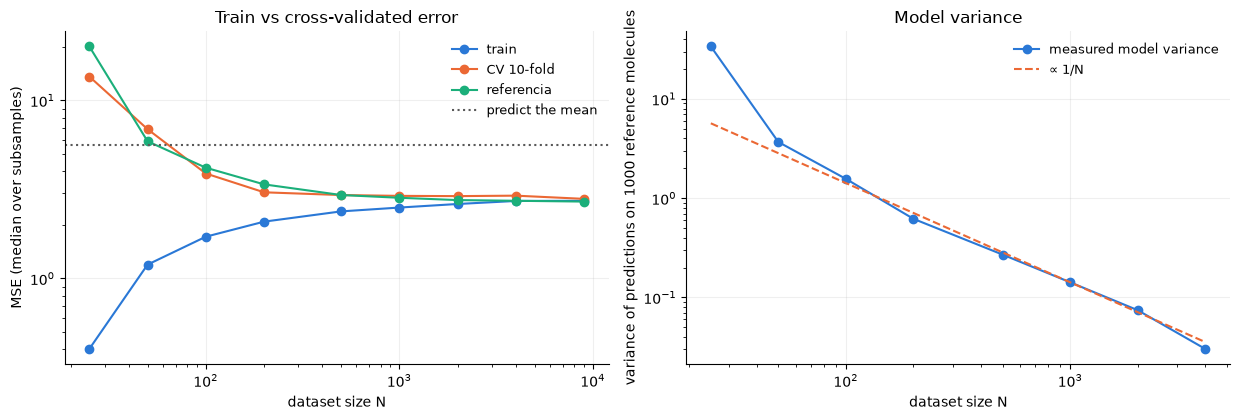

In [4]:
def fit_lineal(x, y):
    # least squares with intercept on features standardized with THIS training set
    mu, sd = x.mean(axis=0), x.std(axis=0)
    sd[sd == 0] = 1          # a descriptor can be constant in a small sample
    c, *_ = np.linalg.lstsq(np.c_[(x - mu) / sd, np.ones(len(x))], y, rcond=None)
    return lambda z: np.c_[(z - mu) / sd, np.ones(len(z))] @ c


rng = np.random.default_rng(4)
perm = rng.permutation(len(y_all))
ref, pool = perm[:1000], perm[1000:]

tamanos = [25, 50, 100, 200, 500, 1000, 2000, 4000, len(pool)]
filas, varianza_modelo = [], {}
for n in tamanos:
    repes = 50 if n <= 1000 else (20 if n < len(pool) else 1)
    preds_ref = []
    for r in range(repes):
        s = rng.choice(pool, n, replace=False) if n < len(pool) else pool
        xs, ys = X_all[s], y_all[s]
        err_folds = []
        for tr, te in KFold(10, shuffle=True, random_state=r).split(xs):
            m = fit_lineal(xs[tr], ys[tr])
            err_folds.append(np.mean((m(xs[te]) - ys[te]) ** 2))
        m = fit_lineal(xs, ys)
        preds_ref.append(m(X_all[ref]))
        filas.append({"N": n, "train": np.mean((m(xs) - ys) ** 2), "CV 10-fold": np.mean(err_folds),
                      "referencia": np.mean((m(X_all[ref]) - y_all[ref]) ** 2)})
    if repes > 1:
        varianza_modelo[n] = np.array(preds_ref).var(axis=0).mean()

res_n = pd.DataFrame(filas).groupby("N").median()
res_n["CV − train"] = res_n["CV 10-fold"] - res_n["train"]
res_n["varianza del modelo"] = pd.Series(varianza_modelo)
print(res_n.round(3).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))
for col, color in zip(["train", "CV 10-fold", "referencia"], COLORES):
    ax1.plot(res_n.index, res_n[col], "o-", color=color, label=col)
ax1.axhline(y_all.var(), color="0.35", linestyle=":", label="predict the mean")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("dataset size N")
ax1.set_ylabel("MSE (median over subsamples)")
ax1.set_title("Train vs cross-validated error")
ax1.legend(frameon=False, fontsize=9)
estilo(ax1)

v = res_n["varianza del modelo"].dropna()
ax2.plot(v.index, v.values, "o-", color=COLORES[0], label="measured model variance")
ax2.plot(v.index, v.loc[1000] * 1000 / v.index.values, "--", color=COLORES[1], label="∝ 1/N")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("dataset size N")
ax2.set_ylabel("variance of predictions on 1000 reference molecules")
ax2.set_title("Model variance")
ax2.legend(frameon=False, fontsize=9)
estilo(ax2)
fig.tight_layout()
fig.savefig("../figuras/03_ej2_tamano_varianza.png", dpi=150)
plt.show()

**Se cumple, y la figura lo enseña de dos maneras.**

**Izquierda: la distancia entre CV y train se cierra.** El error de train **sube** con $N$ (0.402 con 25
moléculas, 2.728 con todas): con pocas moléculas el modelo memoriza, y con muchas ya no puede. El error de
CV **baja** (13.61 → 2.80). La diferencia pasa de **13.2 a 0.07**. Según 3.4, lo que separa el test del train
es sobre todo la varianza; si esa distancia se cierra, es que la varianza baja.

El error sobre las 1000 moléculas de referencia (verde) sigue a la CV, lo que confirma que la CV mide bien
el error real cuando hay datos suficientes. Con 25 moléculas no (13.6 frente a 20.1), como vimos en 3.6.
Con 25 y 50 moléculas el modelo es **peor que predecir la media** (5.61): es la zona de 3.3 donde el número
de parámetros (18) se acerca al de datos.

**Derecha: la varianza medida directamente cae como $1/N$.** La varianza de las predicciones sobre las
moléculas de referencia baja de 33.8 (25 moléculas) a 0.030 (4000). A partir de unas 100 moléculas cae
sobre la línea $\propto 1/N$: 0.270 con 500, 0.142 con 1000, 0.074 con 2000. Duplicar los datos divide la
varianza por dos. Es la misma ley que la del error de una media de réplicas en el laboratorio, $\sigma^2/N$:
los pesos del modelo son, en el fondo, promedios sobre los datos. Con 25 moléculas la varianza está muy
por encima de esa línea porque el modelo está cerca de tener tantos parámetros como datos.

**Lo que no baja con más datos.** Las tres curvas se juntan hacia **2.7**, y de 1000 moléculas en adelante
el error casi no cambia (2.84 → 2.70 en la referencia). Ese resto es sesgo² + ruido. Más datos quitan la
varianza, pero no el sesgo de usar un modelo lineal con 17 descriptores (3.4). Para bajar de 2.7 hay que
cambiar de modelo o de features; lo intentamos en el ejercicio 6.

---
## 3.10.2 Regularización

### Ejercicio 3 — L1 con 35 moléculas

> **Enunciado.** Implementa la **regularización L1** sobre la solubilidad con **$N = 35$ moléculas**.
> Aumenta la intensidad hasta que algunos pesos $w_i$ lleguen a cero. ¿Cuáles son? ¿Por qué crees que
> son esos los primeros?

**Por qué no vale el descenso de gradiente de siempre.** La pérdida es

$$L(\vec w, b) = \frac{1}{N}\sum_i \big(y_i - \vec w\cdot\vec x_i - b\big)^2 + \lambda \sum_k \lvert w_k\rvert$$

La derivada de $\lvert w\rvert$ es $+1$ o $-1$ según el signo, y no existe en 0. Con descenso de
gradiente, un peso que debería ser 0 pasa de un lado al otro en cada paso: se queda oscilando cerca de
0 **sin llegar nunca a 0 exacto**.

**La solución: separar los dos términos (ISTA).** Cada paso se hace en dos tiempos:

1. un paso de descenso de gradiente normal, **solo con el MSE**: $\vec v = \vec w - \eta\,\nabla \text{MSE}$;
2. el ***soft thresholding***, que se encarga del término L1: cada peso se acerca a 0 en $\eta\lambda$, y
   si al hacerlo cruzaría el 0, se queda en 0.

$$w_k \leftarrow \operatorname{sign}(v_k)\,\max\big(\lvert v_k\rvert - \eta\lambda,\ 0\big)$$

El segundo paso es lo que produce los ceros exactos. Es el algoritmo ISTA (*Iterative
Shrinkage-Thresholding Algorithm*). La elección del paso $\eta = 1/L$, con $L$ la curvatura máxima del
MSE (el mayor autovalor de $\frac{2}{N}X^\top X$), es la misma idea que el umbral de estabilidad del
ejercicio 5 del capítulo 2.

**Para comprobarlo**, `sklearn.linear_model.Lasso` resuelve el mismo problema con otro algoritmo. Ojo:
sklearn escribe la pérdida como $\frac{1}{2N}\sum(\dots)^2 + \alpha\sum\lvert w_k\rvert$, con un $\frac12$
delante. Dividiendo nuestra pérdida entre 2 sale la suya, así que $\alpha = \lambda/2$.

Las 35 moléculas se sortean con `random_state=4` y se estandarizan con su propia media y desviación. El
término constante $b$ no se penaliza.

In [5]:
muestra35 = soldata.sample(35, random_state=4)
X35, y35 = muestra35[feature_names].values, muestra35["Solubility"].values
mu35, sd35 = X35.mean(axis=0), X35.std(axis=0)
print("descriptores constantes en la muestra:", [f for f, s in zip(feature_names, sd35) if s == 0])
Z35 = (X35 - mu35) / sd35


def soft_threshold(v, t):
    return np.sign(v) * np.maximum(np.abs(v) - t, 0)


def l1_ista(Z, y, lam, steps=50_000):
    # minimizes mean((y - Z w - b)^2) + lam * sum(|w|)
    n = len(y)
    w, b = np.zeros(Z.shape[1]), y.mean()
    eta = 1 / (2 * np.linalg.eigvalsh(Z.T @ Z / n).max())
    for _ in range(steps):
        r = Z @ w + b - y
        w = soft_threshold(w - eta * 2 * Z.T @ r / n, eta * lam)
        b = b - eta * 2 * r.mean()
    return w, b


print(f"\n{'lambda':>7s} {'pesos = 0':>10s} {'máx. diferencia con sklearn':>28s}")
for lam in [0.05, 0.2, 0.5, 1.0]:
    w_ista, _ = l1_ista(Z35, y35, lam)
    w_sk = Lasso(alpha=lam / 2, max_iter=500_000, tol=1e-12).fit(Z35, y35).coef_
    print(f"{lam:7.2f} {(w_ista == 0).sum():10d} {np.abs(w_ista - w_sk).max():28.1e}")

# the naive version: plain gradient descent on the same loss, with jax.grad
Z35_j, y35_j = jnp.array(Z35), jnp.array(y35)


def l1_loss(w, b, lam):
    return jnp.mean((y35_j - Z35_j @ w - b) ** 2) + lam * jnp.sum(jnp.abs(w))


l1_grad = jax.jit(jax.grad(l1_loss, (0, 1)))
w_gd, b_gd = jnp.zeros(Z35.shape[1]), 0.0
for _ in range(50_000):
    gw, gb = l1_grad(w_gd, b_gd, 0.5)
    w_gd, b_gd = w_gd - 0.002 * gw, b_gd - 0.002 * gb
w_ista, _ = l1_ista(Z35, y35, 0.5)
print("\ncon lambda = 0.5:")
print(f"  ISTA:                  {(w_ista == 0).sum()} pesos exactamente 0")
print(f"  descenso de gradiente: {(np.array(w_gd) == 0).sum()} pesos exactamente 0; "
      f"los que ISTA anula valen entre {np.abs(np.array(w_gd))[w_ista == 0].min():.1e} "
      f"y {np.abs(np.array(w_gd))[w_ista == 0].max():.1e}")

descriptores constantes en la muestra: []

 lambda  pesos = 0  máx. diferencia con sklearn


   0.05          7                      3.0e-07
   0.20         12                      2.3e-11


   0.50         11                      3.2e-11


   1.00         13                      2.5e-12



con lambda = 0.5:
  ISTA:                  11 pesos exactamente 0
  descenso de gradiente: 0 pesos exactamente 0; los que ISTA anula valen entre 2.5e-04 y 1.7e-03


**La implementación funciona**: ISTA y sklearn coinciden a menos de $3 \cdot 10^{-7}$ en todos los pesos,
con dos algoritmos distintos. Con $\lambda = 0.05$ ya hay 7 pesos en 0 exacto, y 13 con $\lambda = 1$.

Un detalle: con $\lambda = 0.2$ hay 12 pesos en 0 y con $\lambda = 0.5$ hay 11. **El camino del lasso no es
monótono**: con features correlacionadas, al anularse una puede volver a entrar otra que ahora explica lo
que la primera explicaba.

**El descenso de gradiente ingenuo no da ni un cero**: los 11 pesos que ISTA anula quedan entre
$2.5 \cdot 10^{-4}$ y $1.7 \cdot 10^{-3}$, oscilando alrededor de 0. En la práctica es casi lo mismo
(ningún peso importa), pero si lo que se busca es **seleccionar features**, hace falta el soft
thresholding.

#### El camino del lasso: en qué orden se anulan

Ahora barremos $\lambda$ de pequeño a grande y miramos cuándo se anula cada peso. En vez de llamar a
ISTA 300 veces usamos `sklearn.linear_model.lasso_path`, que calcula todo el camino de una vez (y que
acabamos de comprobar que resuelve el mismo problema).

Para cada descriptor anotamos el **último $\lambda$ al que sigue vivo** (el mayor $\lambda$ con peso
distinto de 0). Los de valor pequeño son los primeros en caer.

Aprovechamos también que tenemos 9947 moléculas que el modelo no ha visto: medimos el error de test a lo
largo del camino. Es solo para ver qué hace la regularización con 35 moléculas; **no** sirve para elegir
$\lambda$ (eso sería mirar el test, 3.6).

de primero en anularse a último:
                     último lambda vivo  peso sin regularizar  correlación con y
NumAromaticRings                  0.000                -0.867             -0.464
NumValenceElectrons               0.019                -1.780             -0.566
NumSaturatedRings                 0.022                 0.731             -0.114
NumAliphaticRings                 0.049                -0.882             -0.225
NumHDonors                        0.055                 1.294              0.320
TPSA                              0.057                -2.568              0.085
NumRotatableBonds                 0.060                -0.299             -0.356
NumHAcceptors                     0.067                 2.071              0.031
BalabanJ                          0.106                -0.345              0.099
NumHeteroatoms                    0.139                -0.312             -0.015
MolWt                             0.557                 2.217             -0

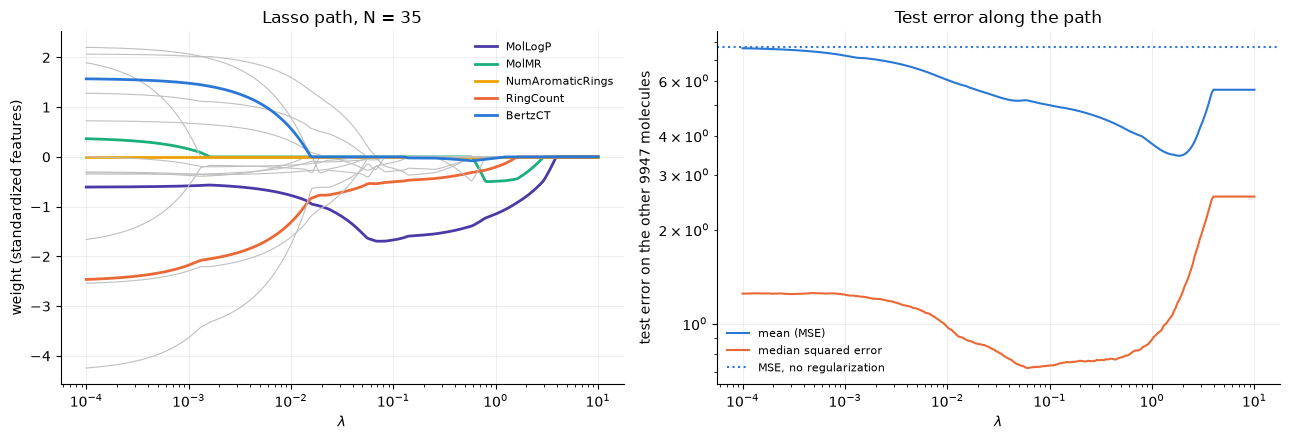

In [6]:
lambdas_path = np.logspace(1, -4, 300)            # sklearn wants them in decreasing order
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    alphas_sk, coefs35, _ = lasso_path(Z35, y35 - y35.mean(), alphas=lambdas_path / 2,
                                       max_iter=500_000, tol=1e-10)
lams35 = 2 * alphas_sk


def ultimo_lambda_vivo(coefs, lams):
    # largest lambda at which each weight is still nonzero (0 if it never enters)
    return np.array([lams[np.nonzero(c)[0]].max() if np.any(c) else 0.0 for c in coefs])


vivo35 = pd.Series(ultimo_lambda_vivo(coefs35, lams35), index=feature_names)
w_ols35 = np.linalg.lstsq(np.c_[Z35, np.ones(35)], y35, rcond=None)[0][:-1]
r_y = [np.corrcoef(Z35[:, j], y35)[0, 1] for j in range(len(feature_names))]
orden = pd.DataFrame({"último lambda vivo": vivo35, "peso sin regularizar": w_ols35,
                      "correlación con y": r_y}).sort_values("último lambda vivo")
print("de primero en anularse a último:")
print(orden.round(3).to_string())

# test error along the path, on the 9947 molecules not in the sample
resto = soldata.drop(muestra35.index)
Z_resto = (resto[feature_names].values - mu35) / sd35
pred_resto = Z_resto @ coefs35 + y35.mean()               # (9947, 300)
err_resto = (pred_resto - resto["Solubility"].values[:, None]) ** 2
mse_path, mediana_path = err_resto.mean(axis=0), np.median(err_resto, axis=0)
ols_resto = (np.c_[Z_resto, np.ones(len(Z_resto))] @ np.linalg.lstsq(np.c_[Z35, np.ones(35)], y35,
                                                                    rcond=None)[0]
             - resto["Solubility"].values) ** 2
i_best = mse_path.argmin()
print(f"\nsin regularizar: MSE test {ols_resto.mean():.2f}, mediana {np.median(ols_resto):.2f}")
print(f"mejor lambda del camino: {lams35[i_best]:.3f} -> MSE test {mse_path[i_best]:.2f}, "
      f"mediana {mediana_path[i_best]:.2f}, {np.sum(coefs35[:, i_best] != 0)} features vivas")
print(f"predecir la media de las 35: MSE test "
      f"{np.mean((y35.mean() - resto['Solubility'].values) ** 2):.2f}")

destacados = orden.index[-4:].tolist() + orden.index[:1].tolist()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
for j, fname in enumerate(feature_names):
    if fname in destacados:
        k = destacados.index(fname)
        ax1.plot(lams35, coefs35[j], color=COLORES[k], linewidth=2, label=fname)
    else:
        ax1.plot(lams35, coefs35[j], color="0.75", linewidth=0.8)
ax1.set_xscale("log")
ax1.set_xlabel("$\\lambda$")
ax1.set_ylabel("weight (standardized features)")
ax1.set_title("Lasso path, N = 35")
ax1.legend(frameon=False, fontsize=8)
estilo(ax1)
ax2.plot(lams35, mse_path, color=COLORES[0], label="mean (MSE)")
ax2.plot(lams35, mediana_path, color=COLORES[1], label="median squared error")
ax2.axhline(ols_resto.mean(), color=COLORES[0], linestyle=":", label="MSE, no regularization")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("$\\lambda$")
ax2.set_ylabel("test error on the other 9947 molecules")
ax2.set_title("Test error along the path")
ax2.legend(frameon=False, fontsize=8)
estilo(ax2)
fig.tight_layout()
fig.savefig("../figuras/03_ej3_lasso_35.png", dpi=150)
plt.show()

**Los primeros en anularse** (de izquierda a derecha en el camino):

1. **`NumAromaticRings`, que no entra nunca** (último $\lambda$ vivo = 0). Es la dependencia exacta:
   `RingCount = NumAromaticRings + NumAliphaticRings`. Cualquier cosa que aporte el número de anillos
   aromáticos se puede escribir con los otros dos, y para el lasso esa forma sale más barata.
2. **`NumValenceElectrons`** (0.019), **`NumSaturatedRings`** (0.022), **`NumAliphaticRings`** (0.049),
   **`NumHDonors`**, **`TPSA`**, **`NumRotatableBonds`**, **`NumHAcceptors`** (0.055–0.067).

**Los últimos supervivientes**: **`MolLogP`** (3.82), **`MolMR`** (2.92), **`RingCount`** (1.58) y
**`BertzCT`** (1.20).

**Por qué este orden.** Hay una regla exacta detrás. En el mínimo de la pérdida L1, un peso se queda en 0
mientras la correlación de su feature con **lo que el resto del modelo todavía no explica** (el residuo)
sea menor que $\lambda$ (con la escala de nuestra pérdida, $\lvert \tfrac{2}{N}\vec z_j \cdot \vec r\rvert < \lambda$).
De ahí salen dos cosas:

- **Con $\lambda$ grande el residuo es casi la $y$ entera**, así que sobrevive la feature más correlacionada
  con $y$. En esta muestra son `MolLogP` ($r = -0.80$) y `MolMR` ($-0.70$), exactamente los dos últimos
  supervivientes.
- **Una feature cae pronto si lo que aporta ya lo aportan otras.** `NumValenceElectrons` tiene $r = -0.57$
  con $y$, nada despreciable, pero es otra medida del tamaño, como `MolWt`, `HeavyAtomCount` y
  `LabuteASA`. Una vez que el modelo tiene el tamaño, a ella no le queda nada propio que explicar. Las otras
  que caen pronto están poco relacionadas con $y$ en esta muestra (`NumSaturatedRings`, $-0.11$) o
  repiten información de otra (`NumHDonors`, `TPSA` y `NumHAcceptors`, las tres miden polaridad).

Fíjate en que **el tamaño del peso sin regularizar no predice el orden**. `TPSA` tenía un peso de $-2.57$ y
cae de las primeras; `MolLogP` tenía $-0.61$ y es la última. Los pesos grandes sin regularizar eran, en
buena parte, cancelaciones entre features correlacionadas (el mismo problema de 3.5).

**La regularización ayuda mucho con 35 moléculas** (panel derecho). Sin regularizar, el MSE en las otras
9947 moléculas es 7.67, peor que predecir la media (5.61). El mejor $\lambda$ del camino (1.84) deja solo 2
features y baja a 3.45. Ese $\lambda$ lo hemos elegido mirando el test, así que es un límite optimista: para
elegirlo de verdad habría que hacer LOOCV dentro de las 35 (3.6). La mediana del error mejora mucho menos
(1.25 → 1.19): lo que arregla la regularización son sobre todo los errores enormes de las extrapolaciones.

### Ejercicio 4 — ¿se anulan siempre las mismas?

> **Enunciado.** Repite el 3 con **varios conjuntos de entrenamiento** distintos. ¿Desaparecen
> siempre las mismas features? A la vista de lo que salga, ¿tiene algún significado qué features se
> van a cero?

Repetimos el camino del lasso con **200 muestras** distintas de 35 moléculas. En cada una ordenamos los 17
descriptores por su último $\lambda$ vivo y les damos un **puesto**: 1 = el último superviviente (el más
"importante" para el lasso), 17 = el primero en anularse. Después miramos:

- cómo se reparte el puesto de cada descriptor entre las 200 muestras;
- la **correlación de Spearman** entre los órdenes de dos muestras: 1 si ordenan los descriptores igual,
  0 si no tienen nada que ver (Spearman es la correlación de Pearson aplicada a los puestos en vez de a
  los valores);
- cuántos **conjuntos de supervivientes** distintos salen a un $\lambda$ fijo (0.3).

                     puesto mediano  último superviviente  entre los 3 últimos  entre los 5 primeros en caer
MolLogP                         1.0                  0.88                 0.99                          0.00
MolWt                           4.5                  0.07                 0.38                          0.18
NumHDonors                      5.0                  0.00                 0.20                          0.04
BalabanJ                        6.0                  0.00                 0.19                          0.04
NumAromaticRings                6.0                  0.00                 0.28                          0.22
NumRotatableBonds               7.0                  0.00                 0.08                          0.10
NumSaturatedRings               8.0                  0.00                 0.04                          0.14
NumHAcceptors                   9.0                  0.00                 0.03                          0.22
NumHeteroatoms     


Spearman entre pares de muestras: media 0.35, percentiles 10-90 0.06 a 0.64
conjuntos de supervivientes distintos con lambda = 0.3: 187 de 200 (tamaño mediano 5)
puesto de los descriptores en nuestra muestra del ejercicio 3: MolLogP 1, MolMR 2


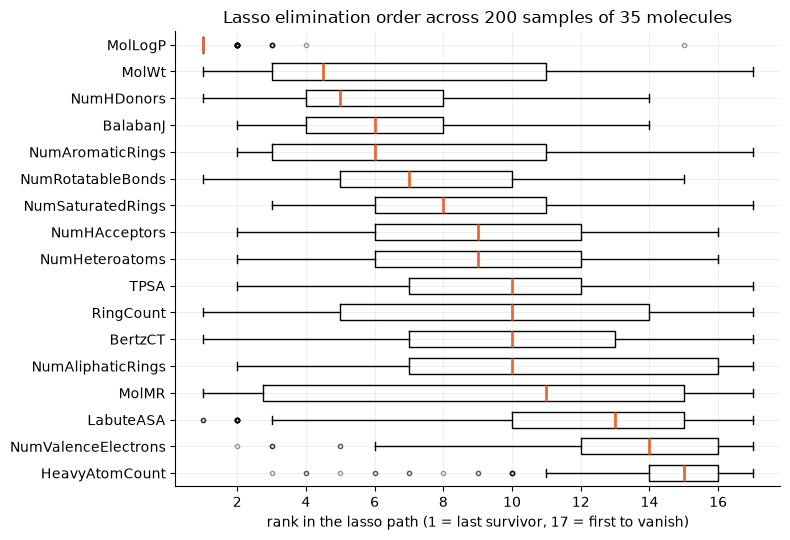

In [7]:
rng = np.random.default_rng(4)
lambdas_rep = np.logspace(1, -4, 200)
vivos, conjuntos = [], []
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for _ in range(200):
        idx = rng.choice(len(y_all), 35, replace=False)
        x, y = X_all[idx], y_all[idx]
        mu, sd = x.mean(axis=0), x.std(axis=0)
        sd[sd == 0] = 1
        a, coefs, _ = lasso_path((x - mu) / sd, y - y.mean(), alphas=lambdas_rep / 2,
                                 max_iter=100_000, tol=1e-6)
        vivos.append(ultimo_lambda_vivo(coefs, 2 * a))
        conjuntos.append(tuple(np.nonzero(coefs[:, np.argmin(np.abs(2 * a - 0.3))])[0]))

vivos = pd.DataFrame(vivos, columns=feature_names)
puesto = vivos.rank(axis=1, ascending=False, method="min")   # 1 = last survivor
tabla_ej4 = pd.DataFrame({
    "puesto mediano": puesto.median(),
    "último superviviente": (puesto == 1).mean(),
    "entre los 3 últimos": (puesto <= 3).mean(),
    "entre los 5 primeros en caer": (puesto >= 13).mean(),
}).sort_values("puesto mediano")
print(tabla_ej4.round(2).to_string())

rhos = [spearmanr(vivos.iloc[i], vivos.iloc[j])[0] for i in range(200) for j in range(i + 1, 200)]
print(f"\nSpearman entre pares de muestras: media {np.mean(rhos):.2f}, "
      f"percentiles 10-90 {np.percentile(rhos, 10):.2f} a {np.percentile(rhos, 90):.2f}")
print(f"conjuntos de supervivientes distintos con lambda = 0.3: {len(set(conjuntos))} de 200 "
      f"(tamaño mediano {np.median([len(c) for c in conjuntos]):.0f})")
print(f"puesto de los descriptores en nuestra muestra del ejercicio 3: MolLogP "
      f"{vivo35.rank(ascending=False)['MolLogP']:.0f}, MolMR {vivo35.rank(ascending=False)['MolMR']:.0f}")

orden_f = tabla_ej4.index.tolist()
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.boxplot([puesto[f] for f in orden_f], orientation="horizontal", widths=0.6,
           medianprops=dict(color=COLORES[1], linewidth=2), flierprops=dict(markersize=3, alpha=0.4))
ax.set_yticks(range(1, len(orden_f) + 1), orden_f)
ax.invert_yaxis()
ax.set_xlabel("rank in the lasso path (1 = last survivor, 17 = first to vanish)")
ax.set_title("Lasso elimination order across 200 samples of 35 molecules")
estilo(ax)
fig.tight_layout()
fig.savefig("../figuras/03_ej4_estabilidad_lasso.png", dpi=150)
plt.show()

**Solo los extremos son estables.**

- **`MolLogP` es el último superviviente en el 88 % de las muestras**, y está entre los 3 últimos en el 99 %.
  Nunca está entre los 5 primeros en caer.
- **Los que caen primero son descriptores de tamaño**: `HeavyAtomCount` está entre los 5 primeros en caer en
  el 84 % de las muestras, `NumValenceElectrons` en el 72 % y `LabuteASA` en el 59 %.
- **Todo lo demás es ruido.** Las cajas del medio van de un puesto 3 a un puesto 11–16. `MolWt` es el último
  superviviente en un 7 % de las muestras y está entre los 5 primeros en caer en un 18 %. `MolMR`, el segundo
  superviviente en nuestra muestra del ejercicio 3, tiene un puesto mediano de 11: lo del ejercicio 3 fue
  cosa de esa muestra.

La correlación de Spearman entre los órdenes de dos muestras es **0.35 de media** (entre 0.06 y 0.64 en el
80 % central): dos muestras se parecen algo, pero poco. Y con $\lambda = 0.3$ salen **187 conjuntos de
supervivientes distintos en 200 muestras**. En 3.5, con 500 moléculas por bootstrap, salieron 149 de 200:
con 35, la selección es todavía más inestable.

**¿Tiene significado qué features se van a cero?** Poco, y hay que leerlo con cuidado:

- **Que `MolLogP` sobreviva sí significa algo**: es con mucho el mejor descriptor individual. Tiene sentido
  químico: logP es un coeficiente de reparto octanol/agua, y la ecuación general de solubilidad de
  Yalkowsky ($\log S \approx 0.5 - 0.01\,(T_f - 25) - \log P$) la pone en el centro.
- **Que un descriptor de tamaño caiga no significa que el tamaño no importe.** Significa que lo representa
  otro. Lo estable es el **grupo** ("hace falta una medida del tamaño"); **qué miembro** del grupo se queda
  lo decide el azar de la muestra. `HeavyAtomCount` cae casi siempre el primero, y el tamaño es una de las
  cosas que más pesan en la solubilidad.
- **Con features correlacionadas y pocos datos, la lista de features del lasso no es un resultado
  científico.** Es la misma conclusión de 3.5 (regla de Harrell: L1 para un modelo compacto, no para
  decidir qué variables importan), ahora más marcada.

### Ejercicio 5 — regularización L-infinito

> **Enunciado.** Implementa la **regularización L-infinito** (norma del supremo), que devuelve el
> máximo de los valores absolutos de los pesos:
>
> $$\lVert \vec w\rVert_\infty = \max_k \lvert w_k\rvert$$

$$L(\vec w, b) = \frac{1}{N}\sum_i \big(y_i - \vec w\cdot\vec x_i - b\big)^2 + \lambda\,\max_k \lvert w_k\rvert$$

**Antes de ejecutar, qué esperar.** L2 castiga cada peso en proporción a su tamaño, y L1 castiga todos
por igual. L-infinito castiga **solo el mayor**. El gradiente del término de penalización es 0 para
todos los pesos menos el más grande. Así que el optimizador baja el mayor hasta que alcanza al segundo;
entonces bajan los dos juntos hasta alcanzar al tercero, y así. Con $\lambda$ creciente, cada vez más
pesos deberían acabar **empatados** en el mismo valor absoluto.

Usamos las 9982 moléculas con los 17 descriptores estandarizados, para ver el efecto limpio sin el ruido
de una muestra pequeña. Primero, la implementación directa en JAX: la pérdida en una línea y
`jax.grad`.

In [8]:
Z_j, y_j = jnp.array(Z_all), jnp.array(y_all)


def linf_loss(w, b, lam):
    return jnp.mean((y_j - Z_j @ w - b) ** 2) + lam * jnp.max(jnp.abs(w))


linf_grad = jax.jit(jax.grad(linf_loss, (0, 1)))

lam = 1.0
w_gd, b_gd = jnp.zeros(Z_all.shape[1]), 0.0
for _ in range(20_000):
    gw, gb = linf_grad(w_gd, b_gd, lam)
    w_gd, b_gd = w_gd - 0.01 * gw, b_gd - 0.01 * gb
w_gd = np.array(w_gd)

print(f"pérdida final con lambda = {lam}: {float(linf_loss(w_gd, b_gd, lam)):.4f}")
print("los 10 mayores |w|:", np.sort(np.abs(w_gd))[::-1][:10].round(4))
print("gradiente de la penalización en el último paso (solo el término lambda*max|w|):")
print(np.array(jax.grad(lambda w: lam * jnp.max(jnp.abs(w)))(jnp.array(w_gd))).round(2))

pérdida final con lambda = 1.0: 3.5551
los 10 mayores |w|: [0.4254 0.4246 0.4208 0.4189 0.4184 0.4152 0.4141 0.4139 0.3864 0.3468]
gradiente de la penalización en el último paso (solo el término lambda*max|w|):
[ 0. -1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


**Casi, pero no del todo.** La pérdida final es 3.5551 y los 8 pesos mayores quedan entre 0.414 y 0.425:
agrupados, pero no iguales.

La última línea explica por qué. El gradiente de $\lambda\max\lvert w_k\rvert$ vale $\pm\lambda$ para el peso
mayor y **0 para todos los demás**. En cada paso solo se empuja el peso más grande, que baja un poco y deja de
serlo; en el paso siguiente el empujado es otro. Los pesos del grupo se turnan en ser "el mayor" y el
resultado es un zigzag que no llega a empatarlos. Es el mismo problema que con L1: la penalización no es
derivable justo donde está la solución.

#### La solución exacta

Igual que con L1, el problema es que el máximo no es derivable en los empates. Y se resuelve igual:
separando el paso del MSE del paso de la penalización. Lo único que cambia es el segundo paso (el
*operador proximal* de la penalización):

| Penalización | Segundo paso |
|---|---|
| L1, $\lambda\sum\lvert w_k\rvert$ | *soft thresholding*: acercar cada peso a 0 en $\eta\lambda$ |
| L∞, $\lambda\max\lvert w_k\rvert$ | restar a $\vec v$ su **proyección sobre la bola L1** de radio $\eta\lambda$ |

La segunda fila sale de que L1 y L∞ son normas **duales**. No hace falta la demostración: lo importante es
que la proyección sobre la bola L1 (el punto más cercano a $\vec v$ cuya suma de valores absolutos no pasa
de un radio) es un cálculo de pocas líneas, con un algoritmo de ordenar y acumular (Duchi et al., 2008).

Usamos la versión acelerada del algoritmo (FISTA, que añade un término de inercia) para converger antes.
La comprobamos contra un optimizador de propósito general de scipy (`SLSQP`), planteando el problema de
otra forma: minimizar $\text{MSE} + \lambda t$ con la restricción $-t \le w_k \le t$ para todo $k$.

Como el MSE solo depende de $\vec w$ a través de $G = Z^\top Z/N$ y $\vec c = Z^\top(\vec y - \bar y)/N$ (y
$b = \bar y$ porque las features están centradas), precalculamos esas dos cantidades y cada paso cuesta
lo mismo tenga el dataset 35 moléculas o 9982.

comprobación contra scipy (SLSQP):


  lambda =  0.1: objetivo FISTA -2.69726273, SLSQP -2.69726273, máx. diferencia en los pesos 9.6e-07
  lambda =  1.0: objetivo FISTA -2.05502451, SLSQP -2.05502451, máx. diferencia en los pesos 2.3e-06


  lambda =  5.0: objetivo FISTA -1.02929074, SLSQP -1.02929074, máx. diferencia en los pesos 1.3e-08


lambda = 1: pérdida exacta 3.5526 (descenso de gradiente: 3.5551)
los 10 mayores |w| exactos: [0.42   0.42   0.42   0.42   0.42   0.42   0.42   0.42   0.3867 0.3465]



L∞: cuántos pesos quedan empatados en el máximo (|w_k| = max|w|, a 1e-6 relativo)
  lambda =  0.01: max|w| = 2.1243, empatados  3 de 17, con el signo de su correlación con y: 10 de 17


  lambda =   0.1: max|w| = 1.4172, empatados  3 de 17, con el signo de su correlación con y: 10 de 17
  lambda =     1: max|w| = 0.4200, empatados  8 de 17, con el signo de su correlación con y: 12 de 17


  lambda =     5: max|w| = 0.1700, empatados 13 de 17, con el signo de su correlación con y: 14 de 17
  lambda =    10: max|w| = 0.0935, empatados 15 de 17, con el signo de su correlación con y: 14 de 17
  lambda =    15: max|w| = 0.0386, empatados 14 de 17, con el signo de su correlación con y: 16 de 17


  lambda =    18: max|w| = 0.0123, empatados 17 de 17, con el signo de su correlación con y: 17 de 17
  lambda =  19.5: max|w| = 0.0021, empatados 17 de 17, con el signo de su correlación con y: 17 de 17
umbral a partir del cual todos los pesos son 0: 2 * sum|c| = 19.81


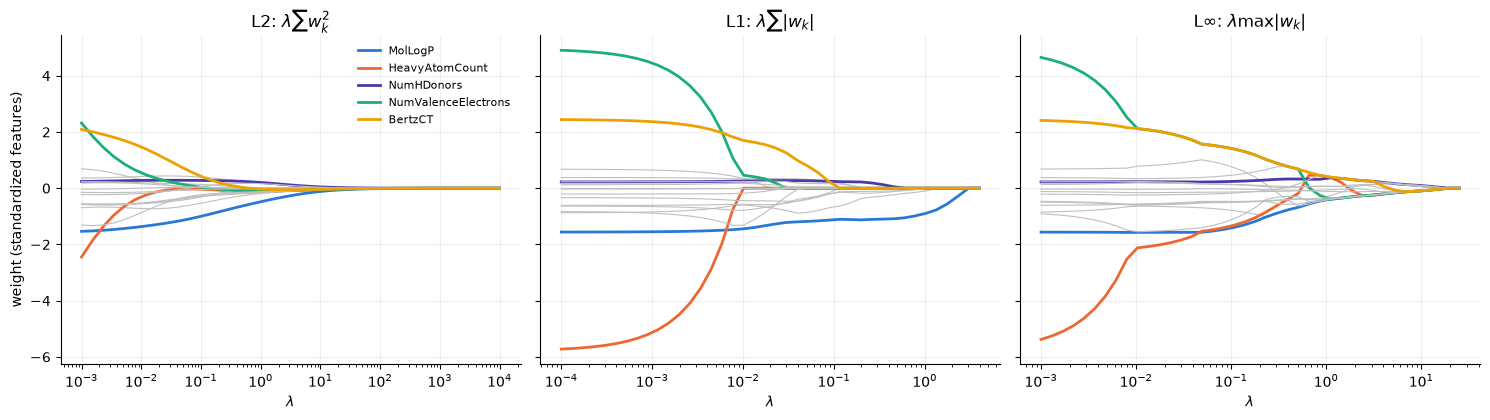

In [9]:
n = len(y_all)
G = Z_all.T @ Z_all / n
c_vec = Z_all.T @ (y_all - y_all.mean()) / n


def proyeccion_bola_l1(v, radio):
    # closest point to v with sum(|u|) <= radio  (Duchi et al. 2008)
    if np.abs(v).sum() <= radio:
        return v
    u = np.sort(np.abs(v))[::-1]
    acum = np.cumsum(u)
    j = np.arange(1, len(u) + 1)
    rho = np.nonzero(u - (acum - radio) / j > 0)[0][-1]
    theta = (acum[rho] - radio) / (rho + 1)
    return np.sign(v) * np.maximum(np.abs(v) - theta, 0)


def prox_l1(v, t):
    return soft_threshold(v, t)


def prox_linf(v, t):
    return v - proyeccion_bola_l1(v, t)


def fista(prox, lam, steps=20_000):
    # minimizes w^T G w - 2 c^T w + lam * R(w), i.e. the MSE (up to a constant) + penalty
    eta = 1 / (2 * np.linalg.eigvalsh(G).max())
    w = np.zeros(len(c_vec))
    z, t = w.copy(), 1.0
    for _ in range(steps):
        w_new = prox(z - eta * 2 * (G @ z - c_vec), eta * lam)
        t_new = (1 + np.sqrt(1 + 4 * t * t)) / 2
        z = w_new + (t - 1) / t_new * (w_new - w)
        w, t = w_new, t_new
    return w


def objetivo_linf(w, lam):
    return w @ G @ w - 2 * c_vec @ w + lam * np.abs(w).max()


print("comprobación contra scipy (SLSQP):")
for lam in [0.1, 1.0, 5.0]:
    w_fista = fista(prox_linf, lam)
    p = len(c_vec)
    res = minimize(lambda v: v[:p] @ G @ v[:p] - 2 * c_vec @ v[:p] + lam * v[p], np.r_[np.zeros(p), 1.0],
                   method="SLSQP", options=dict(maxiter=2000, ftol=1e-14),
                   constraints=[{"type": "ineq", "fun": lambda v: v[p] - v[:p]},
                                {"type": "ineq", "fun": lambda v: v[p] + v[:p]}])
    print(f"  lambda = {lam:4.1f}: objetivo FISTA {objetivo_linf(w_fista, lam):.8f}, SLSQP {res.fun:.8f}, "
          f"máx. diferencia en los pesos {np.abs(res.x[:p] - w_fista).max():.1e}")

w_exacto = fista(prox_linf, 1.0)
print(f"\nlambda = 1: pérdida exacta {float(linf_loss(jnp.array(w_exacto), y_all.mean(), 1.0)):.4f} "
      f"(descenso de gradiente: {float(linf_loss(jnp.array(w_gd), b_gd, 1.0)):.4f})")
print("los 10 mayores |w| exactos:", np.sort(np.abs(w_exacto))[::-1][:10].round(4))

# paths for the three penalties, same loss convention: MSE + lam * R(w)
caminos = {
    "L2: $\\lambda\\sum w_k^2$": np.logspace(-3, 4, 40),
    "L1: $\\lambda\\sum |w_k|$": np.logspace(-4, 0.6, 40),
    "L∞: $\\lambda\\max |w_k|$": np.logspace(-3, np.log10(25), 40),
}
pesos_camino = {}
for nombre, lams in caminos.items():
    if nombre.startswith("L2"):
        pesos_camino[nombre] = np.array([np.linalg.solve(G + l * np.eye(len(c_vec)), c_vec) for l in lams])
    else:
        prox = prox_l1 if nombre.startswith("L1") else prox_linf
        pesos_camino[nombre] = np.array([fista(prox, l, steps=5000) for l in lams])

print("\nL∞: cuántos pesos quedan empatados en el máximo (|w_k| = max|w|, a 1e-6 relativo)")
signo_r = np.sign(c_vec)
for l in [0.01, 0.1, 1, 5, 10, 15, 18, 19.5]:
    w = fista(prox_linf, l)
    m = np.abs(w).max()
    print(f"  lambda = {l:5}: max|w| = {m:.4f}, empatados {np.sum(np.abs(np.abs(w) - m) <= 1e-6 * m):2d} de 17, "
          f"con el signo de su correlación con y: {np.sum(np.sign(w) == signo_r):2d} de 17")
print(f"umbral a partir del cual todos los pesos son 0: 2 * sum|c| = {2 * np.abs(c_vec).sum():.2f}")

fig, axs = plt.subplots(1, 3, figsize=(15, 4.3), sharey=True)
destacados = {"MolLogP": COLORES[0], "HeavyAtomCount": COLORES[1], "NumValenceElectrons": COLORES[2],
              "NumHDonors": COLORES[3], "BertzCT": COLORES[4]}
for ax, (nombre, lams) in zip(axs, caminos.items()):
    W = pesos_camino[nombre]
    for j, fname in enumerate(feature_names):
        if fname in destacados:
            ax.plot(lams, W[:, j], color=destacados[fname], linewidth=2, label=fname)
        else:
            ax.plot(lams, W[:, j], color="0.75", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("$\\lambda$")
    ax.set_title(nombre)
    estilo(ax)
axs[0].set_ylabel("weight (standardized features)")
axs[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig("../figuras/03_ej5_l2_l1_linf.png", dpi=150)
plt.show()

**La solución exacta confirma lo que anticipábamos.** FISTA y SLSQP (dos métodos distintos) dan la
misma pérdida hasta el octavo decimal y los mismos pesos a menos de $2.3 \cdot 10^{-6}$. Con $\lambda = 1$ la
pérdida exacta es 3.5526 (el descenso de gradiente se quedó en 3.5551) y hay **8 pesos empatados exactamente
en 0.42**.

**Cuántos pesos quedan empatados en el máximo:**

| $\lambda$ | 0.01 | 0.1 | 1 | 5 | 10 | 15 | 18 | 19.5 | ≥ 19.81 |
|---|---|---|---|---|---|---|---|---|---|
| empatados (de 17) | 3 | 3 | 8 | 13 | 15 | 14 | 17 | 17 | todos en 0 |
| con el signo de su correlación con $y$ | 10 | 10 | 12 | 14 | 14 | 16 | 17 | 17 | — |

El número de empatados casi siempre crece (con $\lambda = 15$ baja a 14: un peso que cambia de signo pasa por
0 y sale del grupo). Al final **los 17 pesos valen lo mismo en valor absoluto**, y cada uno tiene **el signo
de su correlación con la solubilidad**. En ese límite el modelo es
$\hat y = \bar y + t\sum_k \operatorname{sign}(r_k)\,z_k$: cada descriptor "vota" a favor o en contra con el
mismo peso. Es lo contrario de L1, que se queda con un solo descriptor. Y arregla los signos absurdos de la
multicolinealidad (con $\lambda$ pequeño solo 10 de 17 tienen el signo de su correlación, como vimos en el
capítulo 2).

**La figura compara las tres penalizaciones** con la misma pérdida (MSE + $\lambda R(\vec w)$):

- **L2** encoge todos los pesos poco a poco hacia 0, sin que ninguno llegue.
- **L1** los va anulando **de uno en uno**; `MolLogP` es el último.
- **L∞** recorta **desde arriba**: los pesos que se salen de una banda $[-t, t]$ quedan pegados a sus bordes y
  la banda se va estrechando. Por eso las curvas se juntan en un abanico en vez de caer a 0 por separado.

L∞ se usa poco para regularizar modelos. Su interés está en lo que enseña: **cada penalización tiene su propia
forma**, y esa forma decide cómo se reparte el peso entre features correlacionadas. L2 lo reparte, L1 elige
una y L∞ las iguala.

---
## 3.10.3 Evaluación de modelos

### Ejercicio 6 — el mejor modelo lineal

> **Enunciado.** Construye **el mejor modelo lineal** que puedas para el dataset de solubilidad
> completo y evalúalo con tu mejor criterio. Justifica tanto la elección del modelo como la de la
> evaluación.

Es el ejercicio que junta todo el capítulo. Antes de tocar código hay que fijar **las reglas**, porque
si se deciden después de ver los resultados la evaluación deja de ser honesta.

**1. Qué es "lineal".** Lineal en los parámetros (ejercicio 3 del capítulo 2). Podemos fabricar las
features que queramos; el modelo sigue siendo $\hat y = \vec w\cdot\vec x + b$ y se sigue resolviendo
con mínimos cuadrados.

**2. La métrica.** El MSE, como en todo el capítulo, para poder comparar con 2.80 (10-fold, 3.6) y 5.48
(scaffold split, 3.8). Pero el MSE lo dominan unas pocas moléculas con errores enormes (las mezclas), así
que damos también el **error absoluto mediano**, que dice cómo le va a la molécula típica, y el **peor
error**.

**3. El protocolo: validación cruzada anidada.** Algunos candidatos tienen un hiperparámetro ($\lambda$).
En 3.6 vimos que elegirlo mirando el test es trampa. Así que hay **dos niveles**:
- *fuera*: 10-fold barajado (`random_state=4`) para medir el error;
- *dentro*: en cada ronda, un 5-fold **solo con las moléculas de train** elige $\lambda$. Luego se reentrena
  con todo el train de esa ronda y se predice el segmento de test.

La estandarización también se calcula solo con el train de cada ronda (3.6).

**4. Las moléculas raras se quedan.** Las 573 mezclas y las sales están en el dataset y el modelo se
encontrará moléculas así. Quitarlas del test bajaría el error, pero ya no mediría lo mismo. Lo que sí
haremos es dar su error por separado.

**5. Una segunda evaluación independiente.** Comparar muchos candidatos sobre la misma CV y quedarse con el
mejor es otra forma, más leve, de mirar el test. Por eso el ganador se comprueba además con el **scaffold
split** de 3.8, que no hemos usado para elegir nada.

#### Los candidatos

| Candidato | Features | Qué prueba |
|---|---|---|
| OLS, 17 | los 17 descriptores del dataset | el modelo del capítulo 2 (referencia) |
| ridge, 17 + cuadrados e interacciones | los 17, sus cuadrados y sus productos dos a dos (170) | **funciones de base** (cap. 2, ej. 3): curvatura sin salir de lo lineal |
| ridge, 204 RDKit | los 204 descriptores de 3.3 | más descripción de la molécula |
| ridge, 204 RDKit recortados | lo mismo, **recortando** las features de test al rango del train | ¿se evita la extrapolación? |
| ridge, Morgan | huella de Morgan con **cuentas** (radio 2, 2048 posiciones) | describir la molécula por sus fragmentos |
| ridge, 204 RDKit recortados + Morgan | las dos cosas juntas (2252) | ¿se complementan? |

Dos piezas nuevas:

- **Recortar** (`np.clip`) una feature de test al mínimo y al máximo que tenía en el train. Si una molécula
  tiene 11 dadores de H y el train llegaba a 4, el modelo la ve con 4. Es la rafinosa de 3.2: en lugar de
  dejar que el modelo extrapole con un peso multiplicado por un valor que nunca ha visto, lo limitamos a
  la zona que sí conoce. Es una forma tosca de respetar el dominio de aplicabilidad.
- **Huella de Morgan con cuentas.** En 3.8 usamos la huella de bits para la similitud de Tanimoto: cada
  posición dice si un fragmento circular (un átomo y sus vecinos hasta 2 enlaces de distancia) aparece o
  no. La versión con **cuentas** dice **cuántas veces** aparece. Un modelo lineal sobre ella es una
  **contribución de grupos**, como el método de Joback o los de logP por fragmentos: cada fragmento suma
  (o resta) su parte de la solubilidad.

Con cientos o miles de features, hace falta regularizar. Usamos ridge (L2, la primera opción según el
libro y según Harrell, 3.5), con la solución exacta y $\lambda$ elegido en la CV interna.

In [10]:
# --- features ---
ruta_desc = "../data/rdkit_descriptores.csv"          # cached by 03_regresion.ipynb (section 3.3)
mols = [rdkit.Chem.MolFromSmiles(s) for s in soldata["SMILES"]]
if os.path.exists(ruta_desc):
    desc = pd.read_csv(ruta_desc)
else:
    desc = pd.DataFrame([Descriptors.CalcMolDescriptors(m) if m is not None else {} for m in mols])
    desc.to_csv(ruta_desc, index=False)
desc = desc.drop(columns=["Ipc"]).astype(float)          # same cleaning as in 3.3
no_finitos = (~np.isfinite(desc)).sum()
desc = desc.loc[:, no_finitos <= 0.01 * len(desc)]
validas = np.isfinite(desc.values).all(axis=1) & np.array([m is not None for m in mols])

gen_morgan = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
F_morgan = np.array([gen_morgan.GetCountFingerprintAsNumPy(mols[i]) for i in np.nonzero(validas)[0]],
                    dtype=float)
F_17 = X_all[validas]
F_rdkit = desc.values[validas]
y6 = y_all[validas]
datos6 = soldata[validas].reset_index(drop=True)
mezcla = datos6["Name"].str.contains(";").values

print(f"moléculas: {validas.sum()} de {len(soldata)} (las mismas para todos los candidatos)")
print(f"features: 17 del dataset, {F_rdkit.shape[1]} RDKit, {F_morgan.shape[1]} Morgan "
      f"({(F_morgan.sum(axis=0) > 0).sum()} posiciones usadas alguna vez)")
print(f"cuenta máxima de un mismo fragmento en una molécula: {F_morgan.max():.0f}")
print(f"mezclas: {mezcla.sum()}")

moléculas: 9980 de 9982 (las mismas para todos los candidatos)
features: 17 del dataset, 204 RDKit, 2048 Morgan (2048 posiciones usadas alguna vez)
cuenta máxima de un mismo fragmento en una molécula: 140
mezclas: 573


In [11]:
lambdas6 = np.logspace(-3, 4, 29)
cuadraticas = PolynomialFeatures(degree=2, include_bias=False)


def preparar(X_tr, X_te, recortar=False, cuadrados=False):
    # everything is fitted on the training part only
    if recortar:
        X_te = np.clip(X_te, X_tr.min(axis=0), X_tr.max(axis=0))
    mu, sd = X_tr.mean(axis=0), X_tr.std(axis=0)
    sd[sd == 0] = 1
    Z_tr, Z_te = (X_tr - mu) / sd, (X_te - mu) / sd
    if cuadrados:
        Z_tr, Z_te = cuadraticas.fit_transform(Z_tr), cuadraticas.transform(Z_te)
        mu, sd = Z_tr.mean(axis=0), Z_tr.std(axis=0)
        sd[sd == 0] = 1
        Z_tr, Z_te = (Z_tr - mu) / sd, (Z_te - mu) / sd
    return Z_tr, Z_te


def ridge_camino(Z_tr, y_tr, Z_te, lams):
    # exact ridge for every lambda: loss = mean((y - Zw - b)^2) + lam * sum(w^2), b not penalized
    n = len(y_tr)
    autoval, V = np.linalg.eigh(Z_tr.T @ Z_tr / n)
    cv = V.T @ (Z_tr.T @ (y_tr - y_tr.mean()) / n)
    return np.array([Z_te @ (V @ (cv / (autoval + l))) + y_tr.mean() for l in lams])


def ajustar_predecir(X_tr, y_tr, X_te, ridge=True, **prep):
    if not ridge:
        Z_tr, Z_te = preparar(X_tr, X_te, **prep)
        coef, *_ = np.linalg.lstsq(np.c_[Z_tr, np.ones(len(Z_tr))], y_tr, rcond=None)
        return np.c_[Z_te, np.ones(len(Z_te))] @ coef, None
    err = np.zeros(len(lambdas6))                       # inner 5-fold, train molecules only
    for a, b in KFold(5, shuffle=True, random_state=0).split(X_tr):
        Z_a, Z_b = preparar(X_tr[a], X_tr[b], **prep)
        err += ((ridge_camino(Z_a, y_tr[a], Z_b, lambdas6) - y_tr[b]) ** 2).sum(axis=1)
    lam = lambdas6[err.argmin()]
    Z_tr, Z_te = preparar(X_tr, X_te, **prep)
    return ridge_camino(Z_tr, y_tr, Z_te, [lam])[0], lam


candidatos = {
    "OLS, 17": (F_17, dict(ridge=False)),
    "ridge, 17 + cuadrados e interacciones": (F_17, dict(cuadrados=True)),
    "ridge, 204 RDKit": (F_rdkit, dict()),
    "ridge, 204 RDKit recortados": (F_rdkit, dict(recortar=True)),
    "ridge, Morgan": (F_morgan, dict()),
    "ridge, 204 RDKit recortados + Morgan": (np.c_[F_rdkit, F_morgan], dict(recortar=True)),
}
folds6 = list(KFold(10, shuffle=True, random_state=4).split(F_17))
pred6, mse_folds6, filas = {}, {}, []
for nombre, (F, opciones) in candidatos.items():
    p, lams_elegidas = np.empty(len(y6)), []
    for tr, te in folds6:
        p[te], lam = ajustar_predecir(F[tr], y6[tr], F[te], **opciones)
        lams_elegidas.append(lam)
    e = p - y6
    pred6[nombre] = p
    mse_folds6[nombre] = np.array([np.mean(e[te] ** 2) for _, te in folds6])
    filas.append({"candidato": nombre, "features": 170 if opciones.get("cuadrados") else F.shape[1],
                  "MSE": np.mean(e**2), "RMSE": np.sqrt(np.mean(e**2)), "r2": 1 - np.mean(e**2) / y6.var(),
                  "error abs. mediano": np.median(np.abs(e)), "peor error": np.abs(e).max(),
                  "MSE sin mezclas": np.mean(e[~mezcla] ** 2), "MSE mezclas": np.mean(e[mezcla] ** 2),
                  "lambda (rango)": "—" if lams_elegidas[0] is None
                  else f"{min(lams_elegidas):.3g}–{max(lams_elegidas):.3g}"})
tabla6 = pd.DataFrame(filas).set_index("candidato")
print(f"predecir la media: MSE {y6.var():.3f}\n")
print(tabla6.round(3).to_string())

predecir la media: MSE 5.607

                                       features    MSE   RMSE     r2  error abs. mediano  peor error  MSE sin mezclas  MSE mezclas lambda (rango)
candidato                                                                                                                                        
OLS, 17                                      17  2.792  1.671  0.502               0.976      23.934            2.628        5.488              —
ridge, 17 + cuadrados e interacciones       170  2.282  1.510  0.593               0.798      30.613            2.147        4.486     0.0178–0.1
ridge, 204 RDKit                            204  7.461  2.731 -0.331               0.805     230.344            2.060       96.133    0.001–0.178
ridge, 204 RDKit recortados                 204  2.073  1.440  0.630               0.748      36.401            2.020        2.958   0.001–0.0178
ridge, Morgan                              2048  2.423  1.557  0.568               0.865      

**Qué dice cada fila** (el listón: predecir la media da MSE 5.607):

- **OLS, 17**: **2.792** (RMSE 1.671), el mismo 10-fold de 3.6. Es la referencia que hay que batir.
- **17 + cuadrados e interacciones**: **2.282** (RMSE 1.510), y el error mediano baja de 0.976 a 0.798. El
  capítulo 2 decía que 1.65 de RMSE era "el techo de cualquier modelo lineal sobre estas 17 features". Era
  cierto para las features tal cual; **con funciones de base el modelo sigue siendo lineal y lo supera**. El
  precio: el peor error sube de 23.9 a 30.6, porque los productos de dos features extremas extrapolan
  todavía peor.
- **204 RDKit sin recortar**: MSE **7.461**, $r^2 = -0.33$, **peor que predecir la media**. Y, sin embargo, su
  error mediano (0.805) es mejor que el del OLS, y sin las mezclas el MSE es 2.060. Todo el desastre viene de
  unas pocas extrapolaciones: el peor error es de **230 unidades logarítmicas**, y el MSE de las mezclas es
  96.1. Con 204 descriptores, casi cualquier molécula rara tiene alguno muy fuera del rango del train.
- **204 RDKit recortados**: **2.073**. Recortar arregla el problema de golpe (mezclas: de 96.1 a 2.96). El
  error mediano apenas cambia (0.805 → 0.748): el recorte casi no toca a las moléculas normales, solo impide
  que las raras se salgan.
- **Morgan**: **2.423**. La contribución de grupos funciona mejor que los 17 descriptores, pero peor que los
  204.
- **204 RDKit recortados + Morgan**: **1.873** (RMSE 1.368, $r^2 = 0.666$, error mediano 0.742, peor error
  16.1). El mejor en todas las columnas menos la del error de las mezclas.

Las $\lambda$ elegidas por la CV interna para los descriptores RDKit quedan en el extremo inferior de la
rejilla (0.001–0.018): con casi 9000 moléculas de train y 204 features, la varianza ya es pequeña (ejercicio
2) y apenas hace falta regularizar. **La mejora no viene de la regularización, viene de las features y del
recorte.**

#### ¿Es la diferencia real, o ruido de la CV?

La tabla da un número por candidato, pero cada número es la media de 10 segmentos que también tienen su
incertidumbre (3.6). Como **todos los candidatos se han examinado con los mismos 10 segmentos**, podemos
comparar segmento a segmento: la diferencia de MSE en cada segmento, y su media con su error estándar.
Es una comparación **pareada**, como un $t$ pareado en el laboratorio: las variaciones que comparten los
dos modelos (un segmento con muchas mezclas es difícil para todos) se cancelan.

También miramos el suelo del **ruido experimental**. AqSolDB guarda, para las moléculas medidas más de
una vez, la desviación típica entre medidas (`SD`). Su cuadrado medio da una idea del $\sigma^2$ de 3.4:
lo que ningún modelo puede bajar.

In [12]:
mejor = tabla6["MSE"].idxmin()
print(f"mejor candidato: {mejor}\n")
for nombre in tabla6.index:
    if nombre == mejor:
        continue
    d = mse_folds6[nombre] - mse_folds6[mejor]
    print(f"{nombre:40s} − mejor: {d.mean():+7.3f} ± {d.std(ddof=1) / np.sqrt(len(d)):.3f} (e. estándar); "
          f"el mejor gana en {np.sum(d > 0)} de 10 segmentos")

varias = datos6["Ocurrences"].values > 1
print(f"\nmoléculas medidas más de una vez: {varias.sum()}")
print(f"media de SD^2 entre medidas: {np.mean(datos6['SD'].values[varias] ** 2):.3f}   "
      f"(mediana de SD: {np.median(datos6['SD'].values[varias]):.3f})")
e_mejor = pred6[mejor] - y6
print(f"MSE del mejor candidato en esas mismas moléculas: {np.mean(e_mejor[varias] ** 2):.3f}")

peores = np.argsort(-np.abs(e_mejor))[:8]
print("\nlas 8 peores predicciones del mejor candidato:")
print(pd.DataFrame({"nombre": datos6["Name"].str[:55].values[peores], "real": y6[peores],
                    "predicho": pred6[mejor][peores].round(2), "mezcla": mezcla[peores]}).to_string(index=False))

mejor candidato: ridge, 204 RDKit recortados + Morgan

OLS, 17                                  − mejor:  +0.919 ± 0.061 (e. estándar); el mejor gana en 10 de 10 segmentos
ridge, 17 + cuadrados e interacciones    − mejor:  +0.409 ± 0.118 (e. estándar); el mejor gana en 10 de 10 segmentos
ridge, 204 RDKit                         − mejor:  +5.588 ± 5.337 (e. estándar); el mejor gana en 10 de 10 segmentos
ridge, 204 RDKit recortados              − mejor:  +0.201 ± 0.121 (e. estándar); el mejor gana en 9 de 10 segmentos
ridge, Morgan                            − mejor:  +0.551 ± 0.113 (e. estándar); el mejor gana en 10 de 10 segmentos

moléculas medidas más de una vez: 2236
media de SD^2 entre medidas: 0.266   (mediana de SD: 0.132)
MSE del mejor candidato en esas mismas moléculas: 1.803

las 8 peores predicciones del mejor candidato:
                                                 nombre      real  predicho  mezcla
1,3-dimethyl-5-propylbenzene; 6,6,22,22-tetrabutyloctap -6.806303    -22.

**Las diferencias con el OLS y con las funciones de base son reales**: el ganador es mejor que el OLS por
0.919 ± 0.061 y en los 10 segmentos, y mejor que el modelo con cuadrados por 0.409 ± 0.118, también en los 10.
Frente a los 204 descriptores recortados sin Morgan, la ventaja es de 0.201 ± 0.121, unos 1.7 errores
estándar y 9 de 10 segmentos: **probable, pero no concluyente**. (Frente a los 204 sin recortar, la
incertidumbre es enorme, ± 5.3, porque un solo segmento con una extrapolación de 230 lo decide todo.)

**El suelo del ruido.** En las 2236 moléculas medidas más de una vez, la varianza entre medidas es 0.266 de
media (mediana de la SD: 0.13 unidades logarítmicas). Nuestro mejor modelo tiene un MSE de 1.803 en esas
mismas moléculas. **Unas 1.5 unidades de MSE no son ruido experimental: son sesgo del modelo o de la
representación.** Es el margen que tienen los modelos no lineales del resto del libro. (Es una estimación
aproximada del suelo: las moléculas medidas una sola vez podrían tener más ruido.)

**Las peores predicciones** son las de siempre. De las 8, cinco están marcadas como mezcla. La cuarta,
"1,4-xylene 4-(methoxycarbonyl)benzoic acid...", también lo es: es la mezcla de 24 componentes del ejercicio 2
del capítulo 2, que en el nombre usa espacios en lugar de `;` y se escapa a nuestro criterio. Las otras dos
son compuestos metálicos: una sal de aluminio de un colorante tetrabromado y un compuesto de antimonio que se
predice soluble (0.05) cuando es muy insoluble (−9.02). En las mezclas, los descriptores y las cuentas de
fragmentos se suman sobre todos los componentes, y el modelo ve una "molécula" gigante: predice −22.9 para
una solubilidad real de −6.8. **Están fuera del dominio de aplicabilidad de cualquier modelo que describa una
sola molécula.**

#### La segunda evaluación: scaffold split

El mismo reparto que en 3.8: los scaffolds de Bemis–Murcko ordenados de más raro a más común, y los más
raros a test hasta llenar el 20 %. Entrenamos el modelo del capítulo 2 y el ganador (con $\lambda$
elegido otra vez por 5-fold **dentro** del train) y comparamos. También dibujamos los *parity plots* de la
CV de los dos.

scaffold split: 7984 train, 1996 test


                                      MSE scaffold  error abs. mediano scaffold  MSE 10-fold  lambda
candidato                                                                                           
OLS, 17                                      5.485                        1.029        2.792     NaN
ridge, 204 RDKit recortados + Morgan         4.132                        1.001        1.873   0.316


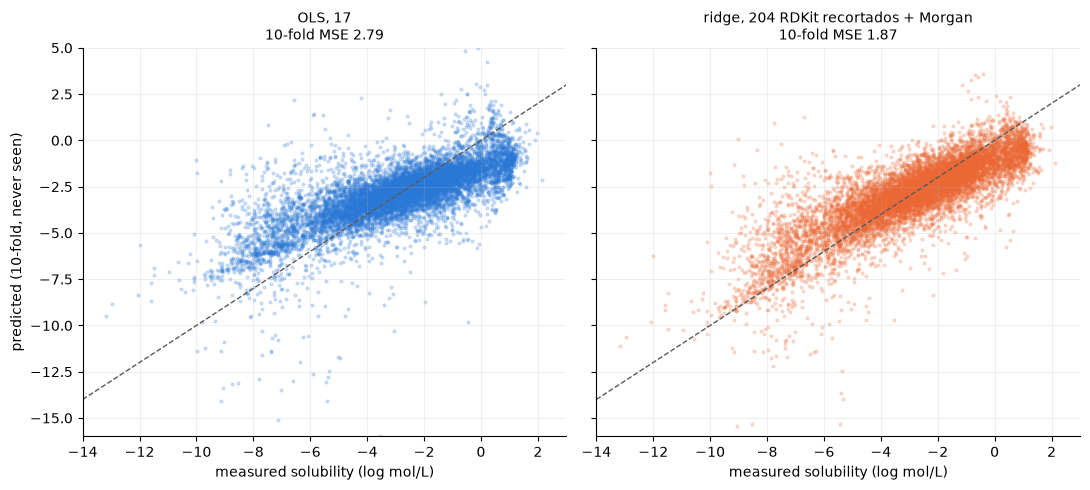

predicciones fuera de los ejes de la figura: [('OLS, 17', np.int64(11)), ('ridge, 204 RDKit recortados + Morgan', np.int64(6))]


In [13]:
scaffolds = pd.Series([MurckoScaffold.MurckoScaffoldSmiles(mol=mols[i]) for i in np.nonzero(validas)[0]])
cuentas = scaffolds.value_counts()
objetivo, en_test, acumulado = int(0.2 * len(scaffolds)), set(), 0
for scaf, cnt in cuentas.iloc[::-1].items():           # rarest first, as in the book
    if acumulado >= objetivo:
        break
    en_test.add(scaf)
    acumulado += cnt
te_scaf = scaffolds.isin(en_test).values
tr_scaf = ~te_scaf
print(f"scaffold split: {tr_scaf.sum()} train, {te_scaf.sum()} test")

filas = []
for nombre in ["OLS, 17", mejor]:
    F, opciones = candidatos[nombre]
    p, lam = ajustar_predecir(F[tr_scaf], y6[tr_scaf], F[te_scaf], **opciones)
    e = p - y6[te_scaf]
    filas.append({"candidato": nombre, "MSE scaffold": np.mean(e**2),
                  "error abs. mediano scaffold": np.median(np.abs(e)),
                  "MSE 10-fold": tabla6.loc[nombre, "MSE"], "lambda": lam})
print(pd.DataFrame(filas).set_index("candidato").round(3).to_string())

fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
for ax, nombre, color in zip(axs, ["OLS, 17", mejor], COLORES):
    ax.scatter(y6, pred6[nombre], s=4, alpha=0.2, color=color, rasterized=True)
    ax.plot([-14, 3], [-14, 3], color="0.35", linestyle="--", linewidth=1)
    ax.set_xlim(-14, 3)
    ax.set_ylim(-16, 5)
    ax.set_xlabel("measured solubility (log mol/L)")
    ax.set_title(f"{nombre}\n10-fold MSE {tabla6.loc[nombre, 'MSE']:.2f}", fontsize=10)
    estilo(ax)
axs[0].set_ylabel("predicted (10-fold, never seen)")
fig.tight_layout()
fig.savefig("../figuras/03_ej6_parity.png", dpi=150)
plt.show()
fuera = [(n, np.sum((pred6[n] < -16) | (pred6[n] > 5))) for n in ["OLS, 17", mejor]]
print("predicciones fuera de los ejes de la figura:", fuera)

**El scaffold split confirma la elección.** El OLS da **5.485**, la misma cifra que en 3.8 (5.48). El
ganador da **4.132**: un 25 % menos. En 10-fold la mejora era del 33 % (2.792 → 1.873), así que con esqueletos
químicos nuevos la ventaja se reduce, pero se mantiene. El error mediano casi no mejora (1.029 → 1.001): igual
que en la CV, lo que se gana está sobre todo en las colas.

**Los dos modelos duplican su error al pasar de 10-fold a scaffold split.** Mejores features no resuelven el
problema de 3.8: predecir esqueletos raros sigue siendo mucho más difícil que predecir moléculas parecidas a
las del train.

**Los parity plots** muestran de dónde sale la mejora. El OLS comprime el rango (la patología del capítulo 2):
las moléculas muy insolubles se predicen demasiado solubles, y las muy solubles, demasiado poco. El ganador sigue mejor la
diagonal en los dos extremos y tiene menos predicciones disparatadas (6 fuera de los ejes de la figura,
frente a 11).

#### Respuesta: el modelo y su evaluación

**El modelo.** Regresión ridge sobre **204 descriptores de RDKit, recortados al rango del train, más la huella
de Morgan con cuentas** (radio 2, 2048 posiciones): 2252 features. Estandarizadas con el train, sin penalizar
el término constante, y $\lambda \approx 0.3$ elegido por validación cruzada interna. Es lineal en los
parámetros y se resuelve de forma exacta.

**Por qué este.**
1. Es el mejor de los seis en validación cruzada anidada: **MSE 1.873** frente a 2.792 del modelo del capítulo
   2, y gana en los 10 segmentos.
2. La ventaja se confirma en una evaluación que no hemos usado para elegir: el **scaffold split** (4.132
   frente a 5.485).
3. Cada decisión responde a algo del capítulo. **Más features** porque el ejercicio 2 dice que el error ya no
   baja con más datos: el límite es el sesgo, no la varianza. **Ridge** porque con 2252 features hace falta
   regularizar, y L2 es la primera opción. **El recorte** porque las extrapolaciones son las que arruinan el
   MSE (3.2, 3.7, 3.8).

Si se prefiere un modelo más sencillo, **los 204 descriptores recortados sin Morgan** quedan a 0.20 ± 0.12:
casi igual de buenos, con la décima parte de features. La diferencia no es concluyente, y es una elección
razonable.

**Por qué esta evaluación.**
1. **10-fold barajado y anidado**: el error se mide con moléculas que el modelo no ha visto, y $\lambda$ y la
   estandarización se deciden solo con el train de cada ronda. Nada del test entra en el entrenamiento.
2. **Varias métricas**: el MSE para comparar con el capítulo, y el error mediano y el peor error, porque el
   MSE lo dominan unas pocas moléculas.
3. **Comparación pareada** entre candidatos, para saber qué diferencias son reales.
4. **Scaffold split** como segunda evaluación, independiente de la elección y más cercana a un uso real
   (moléculas nuevas de verdad).

**Cómo lo contaría en una frase.** Para moléculas parecidas a las de AqSolDB, el error típico es de **0.74
unidades logarítmicas** (mediana) y el RMSE de 1.37. Para esqueletos químicos nuevos, el MSE sube a 4.1. Las
mezclas y los compuestos metálicos quedan fuera de su dominio de aplicabilidad.

**Los límites que quedan.** Elegir el mejor de seis candidatos con la misma CV introduce un pequeño optimismo
(por eso el scaffold split). Y el MSE sigue unas 1.5 unidades por encima del ruido experimental: el resto es
sesgo, y para bajarlo hace falta otro tipo de modelo. Eso es el resto del libro.

---
## Resumen: lo que enseña cada ejercicio

| Ej. | Tema | La idea que hay que retener |
|---|---|---|
| 1 | redundancia sin ruido | sin ruido, las features redundantes no dañan la predicción si los datos determinan los pesos; sí se pierde la interpretación. Si no la determinan (más features que datos, o una muestra que no varía), train 0 y test > 0: **indeterminación**, no ruido |
| 2 | tamaño del dataset | la varianza del modelo cae como **1/N** (0.142 con 1000 moléculas, 0.074 con 2000) y la distancia CV–train se cierra (13.2 → 0.07). El sesgo no baja: todo converge a ~2.7 |
| 3 | L1 con 35 moléculas | hace falta *soft thresholding* para tener ceros exactos. Sobrevive la feature más correlacionada con $y$ (`MolLogP`); caen primero las que repiten información de otras |
| 4 | estabilidad del lasso | solo los extremos son estables (`MolLogP` último en el 88 %, `HeavyAtomCount` entre los primeros en caer en el 84 %). 187 conjuntos distintos en 200 muestras: la lista de features no es un resultado científico |
| 5 | L-infinito | penaliza solo el peso mayor → los pesos se **empatan** en $\pm t$. En el límite, todos iguales con el signo de su correlación. L2 reparte, L1 elige, L∞ iguala |
| 6 | el mejor modelo lineal | ridge con 204 descriptores recortados + Morgan: **1.873** en 10-fold anidado (frente a 2.792) y **4.132** en scaffold split (frente a 5.485). Lo que más ayuda es **recortar** al rango del train y **mejores features**; no la regularización |

**Los dos que más van a pesar en el resto del libro:** el 2 (más datos solo quitan varianza; el sesgo
necesita otro modelo) y el 6 (el error de un modelo depende de a qué moléculas se aplique, y la mejora
viene de la representación de la molécula, que es de lo que van los capítulos de deep learning).